# 02. Lorenz-63 3D-Var with Euler Method

이 노트북에서는 Lorenz-63 모델을 이용해 가장 기본적인 자료동화 실험을 수행한다.

이번 실습의 목표는 다음과 같다.

1. 첫 번째 실습에서 만든 Lorenz-63 truth trajectory를 불러온다.
2. truth에 관측오차를 더해 synthetic observation을 생성한다.
3. 잘못된 초기조건에서 출발한 free run을 수행한다.
4. 관측 시점마다 3D-Var analysis를 수행한다.
5. free run과 DA run의 RMSE를 비교한다.
6. 모든 변수를 관측하는 경우와 일부 변수만 관측하는 경우를 비교한다.

이번 실습에서는 시간적분 방법으로 Euler 방법만 사용한다.

## 1. 라이브러리 불러오기

이번 실습에서는 첫 번째 실습에서 분리한 source module을 재사용한다.

사용하는 주요 모듈은 다음과 같다.

- `lorenz_da.models.lorenz63`
- `lorenz_da.numerics.euler`
- `lorenz_da.observations.operator`
- `lorenz_da.observations.synthetic`
- `lorenz_da.assimilation.three_dvar`
- `lorenz_da.utils.diagnostics`

In [1]:
import sys
from pathlib import Path

# --- bootstrap: 프로젝트 루트의 src/ 를 sys.path 에 추가해 lorenz_da import 를 보장한다 ---
#     editable 설치 위치에 의존하지 않으므로, 프로젝트를 다른 경로로 옮겨도 동작한다.
_p = Path.cwd().resolve()
for _d in (_p, *_p.parents):
    if (_d / "pyproject.toml").exists() or (_d / ".git").exists():
        if str(_d / "src") not in sys.path:
            sys.path.insert(0, str(_d / "src"))
        break

import numpy as np
import matplotlib.pyplot as plt

from lorenz_da.models.lorenz63 import (
    lorenz63_rhs,
    lorenz63_default_initial_condition,
)
from lorenz_da.numerics.euler import (
    euler_step,
    integrate_euler,
)
from lorenz_da.observations.operator import (
    identity_observation_operator,
    partial_observation_operator,
)
from lorenz_da.observations.synthetic import (
    make_observation_indices,
    generate_synthetic_observations,
)
from lorenz_da.assimilation.three_dvar import (
    analysis_3dvar,
    innovation,
)
from lorenz_da.utils.diagnostics import (
    rmse_time_series,
    mean_rmse,
)

from lorenz_da.utils.io import find_project_root, get_output_dirs

## 2. 프로젝트 경로 설정

노트북이 `notebooks/` 안에서 실행될 수도 있고, 프로젝트 루트에서 실행될 수도 있다.

따라서 현재 작업 경로를 확인한 뒤 프로젝트 루트, figure 저장 경로, trajectory 저장 경로를 설정한다.

In [2]:
PROJECT_ROOT = find_project_root()
paths = get_output_dirs(PROJECT_ROOT)
FIGURE_DIR = paths["figures"]
TRAJECTORY_DIR = paths["trajectories"]
ASSIM_DIR = paths["assimilation"]
CKPT_DIR = paths["checkpoints"]

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/sanggyu/projects/lorenz-da-lab
Figure directory: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures


## 3. Truth trajectory 불러오기

첫 번째 실습에서 저장한 Lorenz-63 trajectory를 불러온다.

사용할 파일은 다음과 같다.

```text
outputs/trajectories/lorenz63_truth_euler_dt0005_tmax30.npy
outputs/trajectories/lorenz63_time_dt0005_tmax30.npy

In [3]:
trajectory_path = TRAJECTORY_DIR / "lorenz63_truth_euler_dt0005_tmax30.npy"
time_path = TRAJECTORY_DIR / "lorenz63_time_dt0005_tmax30.npy"

dt = 0.005
tmax = 30.0
nsteps = int(tmax / dt)

if trajectory_path.exists() and time_path.exists():
    truth = np.load(trajectory_path)
    time = np.load(time_path)
    print("기존 truth trajectory를 불러왔다.")
else:
    print("저장된 trajectory가 없어서 새로 생성한다.")

    x0_true = lorenz63_default_initial_condition()
    truth = integrate_euler(
        x0=x0_true,
        dt=dt,
        nsteps=nsteps,
        rhs_func=lorenz63_rhs,
    )
    time = np.arange(nsteps + 1) * dt

    np.save(trajectory_path, truth)
    np.save(time_path, time)

print("truth shape:", truth.shape)
print("time shape:", time.shape)
print("dt:", dt)
print("tmax:", tmax)
print("nsteps:", nsteps)

기존 truth trajectory를 불러왔다.
truth shape: (6001, 3)
time shape: (6001,)
dt: 0.005
tmax: 30.0
nsteps: 6000


## 4. 자료동화 실험 기본 설정

자료동화에서는 다음 세 가지가 필요하다.

1. 모델 예측값 또는 background state
2. 관측값
3. 관측값과 모델값 사이의 차이를 이용한 analysis update

이번 실습에서는 관측을 일정한 시간 간격마다 생성한다.

먼저 모든 상태변수 `x`, `y`, `z`를 관측한다고 가정한다.

즉, observation operator는 단위행렬이다.

$$
H =
\begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1
\end{bmatrix}
$$

In [4]:
# 난수 고정
seed = 42
rng = np.random.default_rng(seed)

# 관측 간격
obs_interval = 20
obs_indices = make_observation_indices(
    nsteps=nsteps,
    obs_interval=obs_interval,
)
obs_times = time[obs_indices]

# 모든 변수를 관측하는 H
H_all = identity_observation_operator(state_dim=3)

# 관측오차 표준편차
obs_std = 2.0

# 관측오차 공분산 R
R_all = (obs_std**2) * np.eye(H_all.shape[0])

print("Number of observation times:", len(obs_indices))
print("Observation interval in model steps:", obs_interval)
print("Observation interval in time:", obs_interval * dt)
print("H_all:")
print(H_all)
print("R_all:")
print(R_all)

Number of observation times: 300
Observation interval in model steps: 20
Observation interval in time: 0.1
H_all:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
R_all:
[[4. 0. 0.]
 [0. 4. 0.]
 [0. 0. 4.]]


## 5. Synthetic observation 생성

Synthetic observation은 truth에 관측오차를 더해서 만든다.

관측식은 다음과 같다.

$$
\mathbf{y} = H \mathbf{x}^{true} + \epsilon
$$

여기서

- $\mathbf{y}$: 관측값
- $H$: observation operator
- $\mathbf{x}^{true}$: 참값
- $\epsilon$: 관측오차

관측오차는 평균 0, 표준편차 `obs_std`인 Gaussian noise로 둔다.

In [5]:
observations_all = generate_synthetic_observations(
    truth=truth,
    obs_indices=obs_indices,
    H=H_all,
    obs_std=obs_std,
    rng=rng,
)

print("observations_all shape:", observations_all.shape)
print("first observation:", observations_all[0])

observations_all shape: (300, 3)
first observation: [2.67205893 2.25665485 2.58214822]


## 6. 관측값 확인

먼저 `x` 변수에 대해 truth와 synthetic observation을 비교한다.

관측값은 truth에 noise를 더한 값이므로, truth 주변에 흩어진 점으로 나타난다.

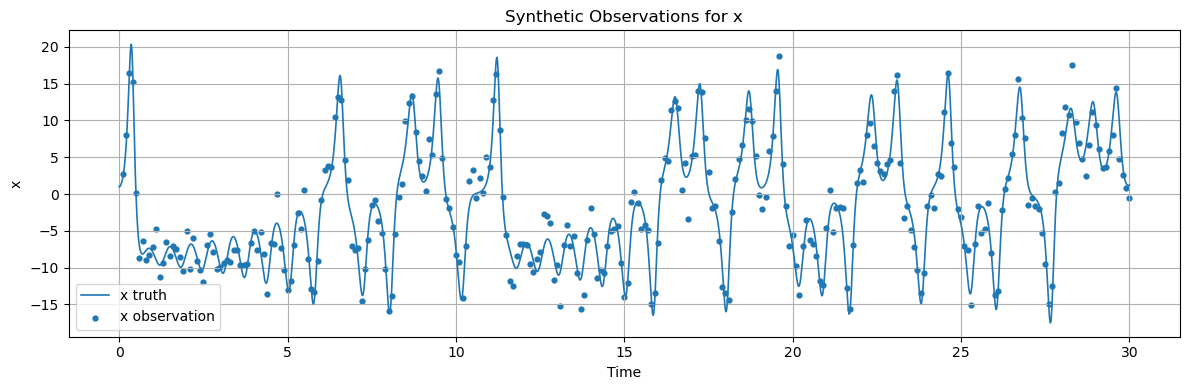

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/02_observations_x_allvars.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(time, truth[:, 0], label="x truth", linewidth=1.2)
ax.scatter(obs_times, observations_all[:, 0], label="x observation", s=12)

ax.set_xlabel("Time")
ax.set_ylabel("x")
ax.set_title("Synthetic Observations for x")
ax.legend()
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "02_observations_x_allvars.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)

## 7. 3D-Var analysis 식

이번 실습에서 사용하는 analysis update는 다음과 같다.

$$
\mathbf{x}^a =
\mathbf{x}^b + K(\mathbf{y} - H\mathbf{x}^b)
$$

여기서

- $\mathbf{x}^b$: background state 또는 forecast state
- $\mathbf{x}^a$: analysis state
- $\mathbf{y}$: observation
- $H$: observation operator
- $\mathbf{y} - H\mathbf{x}^b$: innovation
- $K$: gain matrix

Gain matrix는 다음과 같다.

$$
K = B H^T (H B H^T + R)^{-1}
$$

여기서

- $B$: background error covariance
- $R$: observation error covariance

즉, 3D-Var는 모델 예측값과 관측값의 차이를 이용해 모델 상태를 보정한다.

In [7]:
# background error covariance
bg_std = 4.0
B_diag = (bg_std**2) * np.eye(3)

print("B_diag:")
print(B_diag)

B_diag:
[[16.  0.  0.]
 [ 0. 16.  0.]
 [ 0.  0. 16.]]


## 8. Free run과 DA run 수행

이제 두 가지 실험을 수행한다.

### Free run

Free run은 관측을 사용하지 않고, 잘못된 초기조건에서 모델만 적분한 결과이다.

### DA run

DA run은 모델을 적분하다가 관측 시점이 되면 3D-Var analysis를 수행한다.

초기조건은 truth와 일부러 다르게 둔다.

$$
\mathbf{x}_0^b = \mathbf{x}_0^{true} + [5, -5, 8]
$$

In [8]:
# 초기조건
x0_true = truth[0]
x0_background = x0_true + np.array([5.0, -5.0, 8.0])

# 저장 배열
free_run = np.zeros_like(truth)
da_run_all = np.zeros_like(truth)

free_run[0] = x0_background
da_run_all[0] = x0_background

# 관측 시점 빠른 확인을 위한 set
obs_index_set = set(obs_indices.tolist())
obs_counter = 0

for n in range(nsteps):
    # Free run
    free_run[n + 1] = euler_step(
        state=free_run[n],
        dt=dt,
        rhs_func=lorenz63_rhs,
    )

    # DA forecast
    xb = euler_step(
        state=da_run_all[n],
        dt=dt,
        rhs_func=lorenz63_rhs,
    )

    # 관측 시점이면 analysis 수행
    if (n + 1) in obs_index_set:
        y = observations_all[obs_counter]

        xa = analysis_3dvar(
            xb=xb,
            y=y,
            H=H_all,
            B=B_diag,
            R=R_all,
        )

        da_run_all[n + 1] = xa
        obs_counter += 1
    else:
        da_run_all[n + 1] = xb

print("Free run and DA run completed.")
print("Number of assimilated observations:", obs_counter)

Free run and DA run completed.
Number of assimilated observations: 300


## 9. 모든 변수를 관측한 경우의 시계열 비교

모든 변수를 관측하고, 관측 시점마다 3D-Var analysis를 수행한 결과를 확인한다.

자료동화가 잘 작동하면 DA run이 free run보다 truth에 더 가깝게 유지되어야 한다.

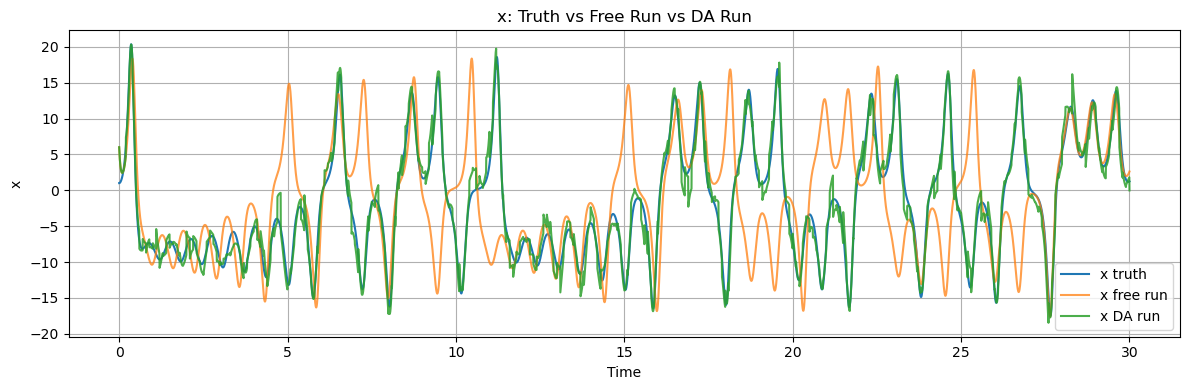

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/02_allvars_3dvar_x_timeseries.png


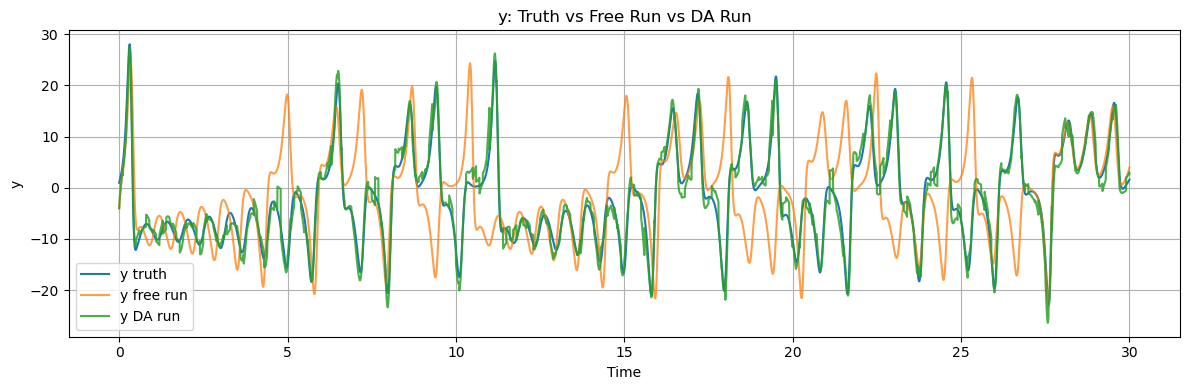

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/02_allvars_3dvar_y_timeseries.png


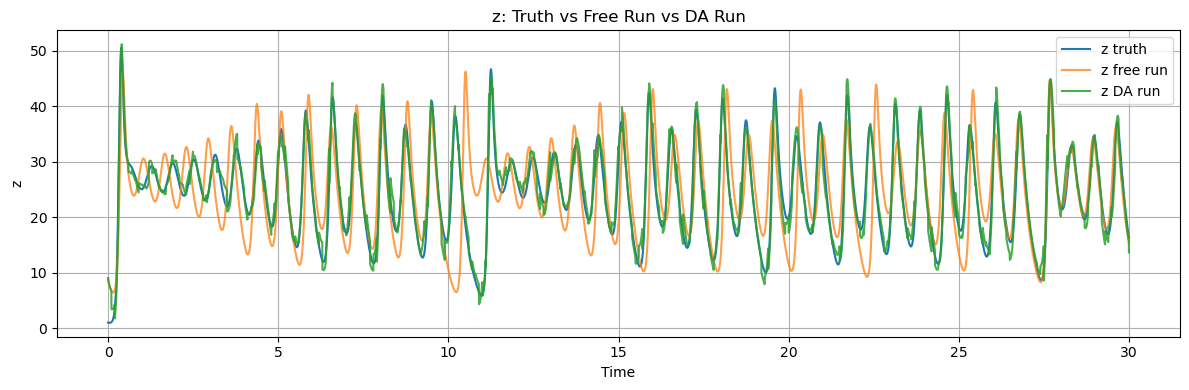

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/02_allvars_3dvar_z_timeseries.png


In [9]:
var_names = ["x", "y", "z"]

for i, name in enumerate(var_names):
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(time, truth[:, i], label=f"{name} truth", linewidth=1.5)
    ax.plot(time, free_run[:, i], label=f"{name} free run", alpha=0.75)
    ax.plot(time, da_run_all[:, i], label=f"{name} DA run", alpha=0.85)

    ax.set_xlabel("Time")
    ax.set_ylabel(name)
    ax.set_title(f"{name}: Truth vs Free Run vs DA Run")
    ax.legend()
    ax.grid(True)

    fig.tight_layout()

    fig_path = FIGURE_DIR / f"02_allvars_3dvar_{name}_timeseries.png"
    fig.savefig(fig_path, dpi=150)

    plt.show()

    print("Saved figure:", fig_path)

## 10. RMSE 비교

free run과 DA run의 RMSE를 계산한다.

각 시간에서의 RMSE는 다음과 같이 계산한다.

$$
RMSE(t) =
\sqrt{
\frac{1}{3}
\left[
(x-x^{true})^2
+
(y-y^{true})^2
+
(z-z^{true})^2
\right]
}
$$

DA run의 평균 RMSE가 free run보다 작다면, 자료동화가 예측을 개선한 것이다.

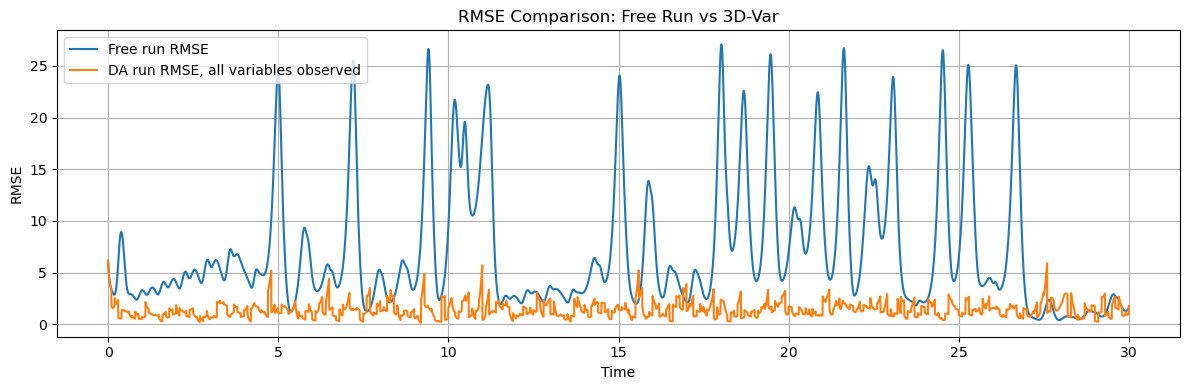

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/02_allvars_3dvar_rmse.png
Mean RMSE
Free run: 7.16670764914493
DA run  : 1.4099328068522763


In [10]:
free_rmse = rmse_time_series(free_run, truth)
da_rmse_all = rmse_time_series(da_run_all, truth)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(time, free_rmse, label="Free run RMSE")
ax.plot(time, da_rmse_all, label="DA run RMSE, all variables observed")

ax.set_xlabel("Time")
ax.set_ylabel("RMSE")
ax.set_title("RMSE Comparison: Free Run vs 3D-Var")
ax.legend()
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "02_allvars_3dvar_rmse.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)
print("Mean RMSE")
print("Free run:", mean_rmse(free_run, truth))
print("DA run  :", mean_rmse(da_run_all, truth))

## 11. 자료동화 결과 저장

이후 실습에서 재사용할 수 있도록 free run과 DA run을 저장한다.

In [11]:
free_run_path = ASSIM_DIR / "02_free_run_euler.npy"
da_run_all_path = ASSIM_DIR / "02_3dvar_allvars_euler.npy"
obs_all_path = ASSIM_DIR / "02_observations_allvars.npy"
obs_indices_path = ASSIM_DIR / "02_obs_indices.npy"

np.save(free_run_path, free_run)
np.save(da_run_all_path, da_run_all)
np.save(obs_all_path, observations_all)
np.save(obs_indices_path, obs_indices)

print("Saved free run:", free_run_path)
print("Saved DA run:", da_run_all_path)
print("Saved observations:", obs_all_path)
print("Saved obs indices:", obs_indices_path)

Saved free run: /Users/sanggyu/projects/lorenz-da-lab/outputs/assimilation/02_free_run_euler.npy
Saved DA run: /Users/sanggyu/projects/lorenz-da-lab/outputs/assimilation/02_3dvar_allvars_euler.npy
Saved observations: /Users/sanggyu/projects/lorenz-da-lab/outputs/assimilation/02_observations_allvars.npy
Saved obs indices: /Users/sanggyu/projects/lorenz-da-lab/outputs/assimilation/02_obs_indices.npy


## 12. 실험 2: x만 관측하는 경우

지금까지는 `x`, `y`, `z`를 모두 관측했다.

하지만 실제 자료동화에서는 모든 상태변수를 직접 관측하기 어렵다.

이번에는 `x`만 관측한다고 가정한다.

Lorenz-63 상태벡터가 다음과 같을 때,

$$
\mathbf{x} = [x, y, z]^T
$$

`x`만 관측하는 observation operator는 다음과 같다.

$$
H =
\begin{bmatrix}
1 & 0 & 0
\end{bmatrix}
$$

In [12]:
# x만 관측
H_x = partial_observation_operator(
    observed_indices=[0],
    state_dim=3,
)

R_x = np.array([[obs_std**2]])

# x만 관측하는 synthetic observation 생성
rng = np.random.default_rng(seed)

observations_x = generate_synthetic_observations(
    truth=truth,
    obs_indices=obs_indices,
    H=H_x,
    obs_std=obs_std,
    rng=rng,
)

print("H_x:")
print(H_x)
print("R_x:")
print(R_x)
print("observations_x shape:", observations_x.shape)

H_x:
[[1. 0. 0.]]
R_x:
[[4.]]
observations_x shape: (300, 1)


## 13. x만 관측하고 diagonal B를 사용하는 경우

먼저 $B$를 대각행렬로 둔다.

대각행렬 $B$는 변수 간 background error covariance가 없다고 가정하는 것이다.

즉, `x` 관측 정보는 주로 `x` 성분에만 직접 반영된다.

In [13]:
da_run_x_diagB = np.zeros_like(truth)
da_run_x_diagB[0] = x0_background

obs_counter = 0

for n in range(nsteps):
    xb = euler_step(
        state=da_run_x_diagB[n],
        dt=dt,
        rhs_func=lorenz63_rhs,
    )

    if (n + 1) in obs_index_set:
        y = observations_x[obs_counter]

        xa = analysis_3dvar(
            xb=xb,
            y=y,
            H=H_x,
            B=B_diag,
            R=R_x,
        )

        da_run_x_diagB[n + 1] = xa
        obs_counter += 1
    else:
        da_run_x_diagB[n + 1] = xb

print("x-only observation with diagonal B completed.")
print("Number of assimilated observations:", obs_counter)

x-only observation with diagonal B completed.
Number of assimilated observations: 300


## 14. x만 관측한 경우의 RMSE 확인

`x`만 관측하고 diagonal B를 사용한 DA run을 free run과 비교한다.

모든 변수를 관측한 경우보다 성능이 낮아질 수 있다.

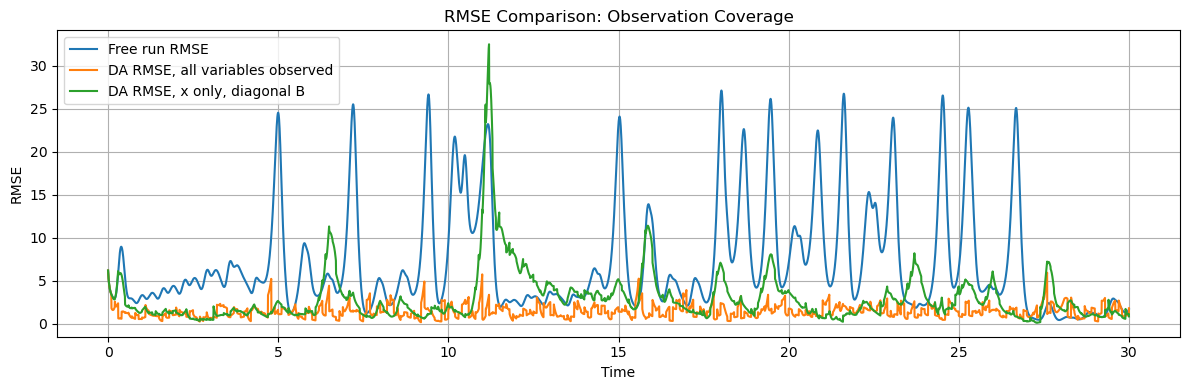

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/02_xobs_diagB_rmse.png
Mean RMSE
Free run                    : 7.16670764914493
DA, all variables observed  : 1.4099328068522763
DA, x only, diagonal B      : 2.934308092472307


In [14]:
da_rmse_x_diagB = rmse_time_series(da_run_x_diagB, truth)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(time, free_rmse, label="Free run RMSE")
ax.plot(time, da_rmse_all, label="DA RMSE, all variables observed")
ax.plot(time, da_rmse_x_diagB, label="DA RMSE, x only, diagonal B")

ax.set_xlabel("Time")
ax.set_ylabel("RMSE")
ax.set_title("RMSE Comparison: Observation Coverage")
ax.legend()
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "02_xobs_diagB_rmse.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)
print("Mean RMSE")
print("Free run                    :", mean_rmse(free_run, truth))
print("DA, all variables observed  :", mean_rmse(da_run_all, truth))
print("DA, x only, diagonal B      :", mean_rmse(da_run_x_diagB, truth))

## 15. 실험 3: x만 관측하고 correlated B를 사용하는 경우

이번에는 $B$에 비대각 성분을 넣는다.

비대각 성분은 변수 간 background error covariance를 의미한다.

예를 들어 $B_{xy}$가 0이 아니면, `x`의 오차와 `y`의 오차가 서로 관련되어 있다고 가정하는 것이다.

이 경우 `x`만 관측하더라도 analysis update가 `y`, `z`에도 전달될 수 있다.

In [15]:
B_corr = np.array(
    [
        [16.0, 8.0, 4.0],
        [8.0, 16.0, 6.0],
        [4.0, 6.0, 16.0],
    ]
)

eigvals = np.linalg.eigvals(B_corr)

print("B_corr:")
print(B_corr)
print("Eigenvalues of B_corr:")
print(eigvals)

B_corr:
[[16.  8.  4.]
 [ 8. 16.  6.]
 [ 4.  6. 16.]]
Eigenvalues of B_corr:
[28.14934717  7.62423481 12.22641803]


## 16. x만 관측하고 correlated B로 3D-Var 수행

관측은 여전히 `x`만 사용한다.

하지만 $B$에 변수 간 covariance가 있으므로, `x` 관측 정보가 `y`, `z`에도 간접적으로 전달된다.

In [16]:
da_run_x_corrB = np.zeros_like(truth)
da_run_x_corrB[0] = x0_background

obs_counter = 0

for n in range(nsteps):
    xb = euler_step(
        state=da_run_x_corrB[n],
        dt=dt,
        rhs_func=lorenz63_rhs,
    )

    if (n + 1) in obs_index_set:
        y = observations_x[obs_counter]

        xa = analysis_3dvar(
            xb=xb,
            y=y,
            H=H_x,
            B=B_corr,
            R=R_x,
        )

        da_run_x_corrB[n + 1] = xa
        obs_counter += 1
    else:
        da_run_x_corrB[n + 1] = xb

print("x-only observation with correlated B completed.")
print("Number of assimilated observations:", obs_counter)

x-only observation with correlated B completed.
Number of assimilated observations: 300


## 17. Diagonal B와 correlated B 비교

이제 다음 네 가지를 비교한다.

1. Free run
2. 모든 변수 관측 + diagonal B
3. x만 관측 + diagonal B
4. x만 관측 + correlated B

핵심적으로 볼 점은 다음이다.

- 모든 변수를 관측하면 DA 성능이 가장 안정적일 가능성이 높다.
- x만 관측하고 diagonal B를 쓰면, 관측 정보가 제한적으로 반영된다.
- x만 관측하더라도 correlated B를 쓰면, 관측되지 않은 변수도 간접적으로 보정될 수 있다.

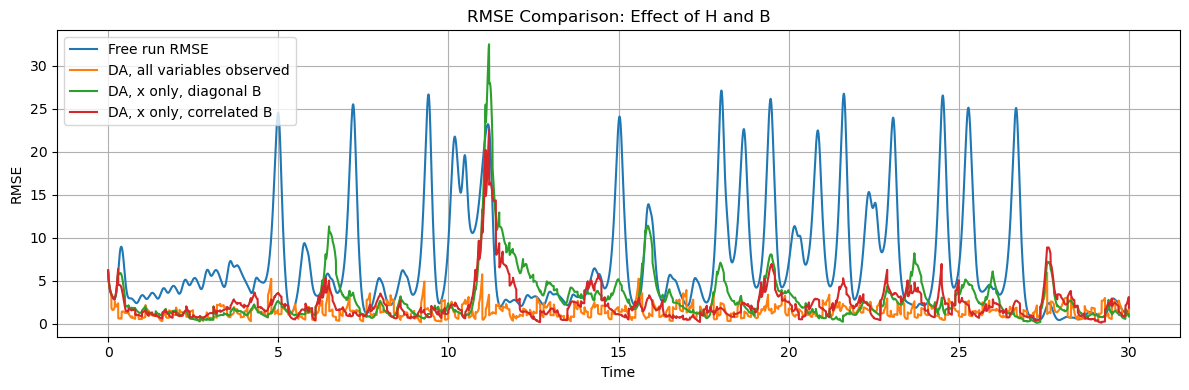

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/02_rmse_comparison_H_B.png
Mean RMSE
Free run                    : 7.16670764914493
DA, all variables observed  : 1.4099328068522763
DA, x only, diagonal B      : 2.934308092472307
DA, x only, correlated B    : 2.27272404052253


In [17]:
da_rmse_x_corrB = rmse_time_series(da_run_x_corrB, truth)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(time, free_rmse, label="Free run RMSE")
ax.plot(time, da_rmse_all, label="DA, all variables observed")
ax.plot(time, da_rmse_x_diagB, label="DA, x only, diagonal B")
ax.plot(time, da_rmse_x_corrB, label="DA, x only, correlated B")

ax.set_xlabel("Time")
ax.set_ylabel("RMSE")
ax.set_title("RMSE Comparison: Effect of H and B")
ax.legend()
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "02_rmse_comparison_H_B.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)
print("Mean RMSE")
print("Free run                    :", mean_rmse(free_run, truth))
print("DA, all variables observed  :", mean_rmse(da_run_all, truth))
print("DA, x only, diagonal B      :", mean_rmse(da_run_x_diagB, truth))
print("DA, x only, correlated B    :", mean_rmse(da_run_x_corrB, truth))

## 18. 변수별 시계열 비교

RMSE만 보면 전체적인 오차 크기는 알 수 있지만, 어떤 변수가 어떻게 개선되었는지는 확인하기 어렵다.

따라서 `x`, `y`, `z` 각각에 대해 다음 세 결과를 비교한다.

1. truth
2. x만 관측 + diagonal B
3. x만 관측 + correlated B

특히 `y`, `z`에서 correlated B의 효과가 있는지 확인한다.

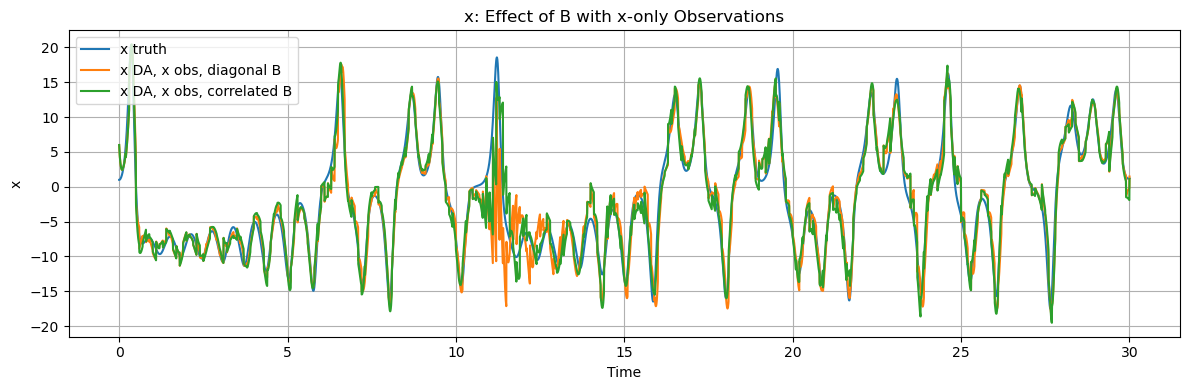

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/02_xobs_diagB_vs_corrB_x.png


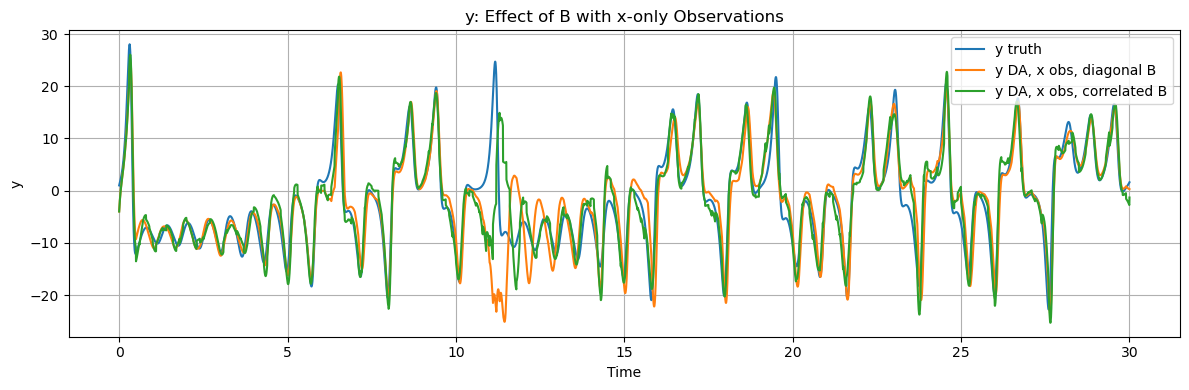

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/02_xobs_diagB_vs_corrB_y.png


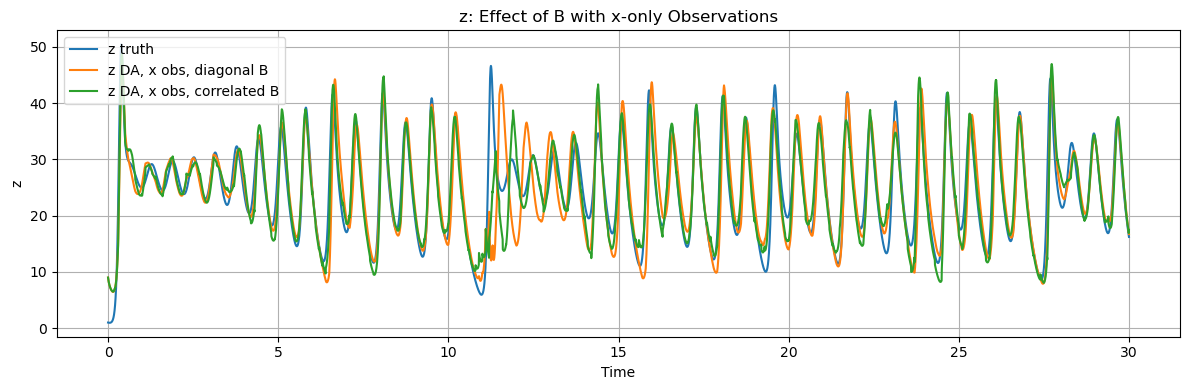

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/02_xobs_diagB_vs_corrB_z.png


In [18]:
for i, name in enumerate(var_names):
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(time, truth[:, i], label=f"{name} truth", linewidth=1.5)
    ax.plot(time, da_run_x_diagB[:, i], label=f"{name} DA, x obs, diagonal B")
    ax.plot(time, da_run_x_corrB[:, i], label=f"{name} DA, x obs, correlated B")

    ax.set_xlabel("Time")
    ax.set_ylabel(name)
    ax.set_title(f"{name}: Effect of B with x-only Observations")
    ax.legend()
    ax.grid(True)

    fig.tight_layout()

    fig_path = FIGURE_DIR / f"02_xobs_diagB_vs_corrB_{name}.png"
    fig.savefig(fig_path, dpi=150)

    plt.show()

    print("Saved figure:", fig_path)

## 19. Innovation 확인

Innovation은 관측값과 background state를 관측공간으로 변환한 값의 차이이다.

$$
d = y - Hx^b
$$

Innovation이 작다는 것은 모델 예측이 관측과 잘 맞고 있다는 의미이다.

여기서는 x만 관측한 경우에 대해 diagonal B와 correlated B의 innovation을 비교한다.

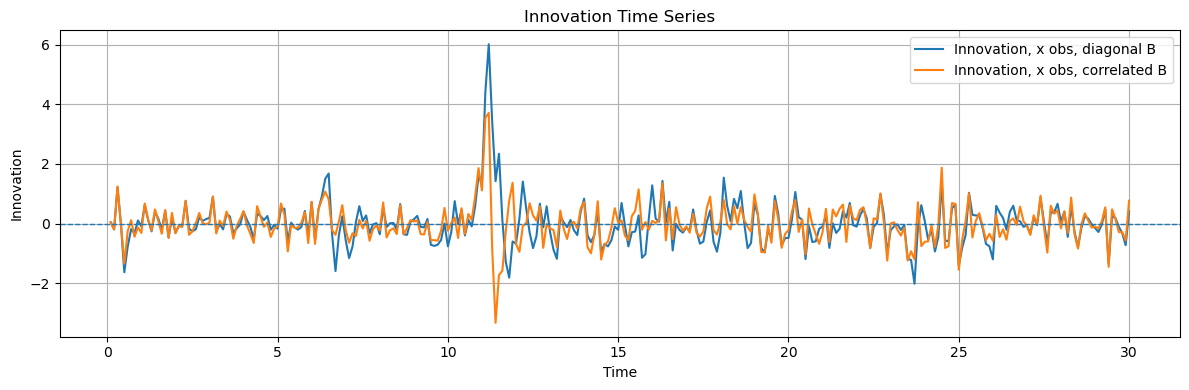

Saved figure: /Users/sanggyu/projects/lorenz-da-lab/outputs/figures/02_innovation_xobs_diagB_vs_corrB.png


In [19]:
def collect_innovations(da_run, observations, obs_indices, H):
    values = []

    for i, idx in enumerate(obs_indices):
        xb = da_run[idx]
        y = observations[i]
        values.append(innovation(xb=xb, y=y, H=H))

    return np.asarray(values)


innov_x_diagB = collect_innovations(
    da_run=da_run_x_diagB,
    observations=observations_x,
    obs_indices=obs_indices,
    H=H_x,
)

innov_x_corrB = collect_innovations(
    da_run=da_run_x_corrB,
    observations=observations_x,
    obs_indices=obs_indices,
    H=H_x,
)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(obs_times, innov_x_diagB[:, 0], label="Innovation, x obs, diagonal B")
ax.plot(obs_times, innov_x_corrB[:, 0], label="Innovation, x obs, correlated B")
ax.axhline(0.0, linestyle="--", linewidth=1.0)

ax.set_xlabel("Time")
ax.set_ylabel("Innovation")
ax.set_title("Innovation Time Series")
ax.legend()
ax.grid(True)

fig.tight_layout()

fig_path = FIGURE_DIR / "02_innovation_xobs_diagB_vs_corrB.png"
fig.savefig(fig_path, dpi=150)

plt.show()

print("Saved figure:", fig_path)

## 20. 최종 결과 저장

이번 실습에서 만든 주요 결과를 저장한다.

저장하는 항목은 다음과 같다.

1. free run
2. 모든 변수 관측 3D-Var 결과
3. x만 관측 + diagonal B 결과
4. x만 관측 + correlated B 결과
5. x만 관측한 observation

In [20]:
np.save(ASSIM_DIR / "02_3dvar_xobs_diagB_euler.npy", da_run_x_diagB)
np.save(ASSIM_DIR / "02_3dvar_xobs_corrB_euler.npy", da_run_x_corrB)
np.save(ASSIM_DIR / "02_observations_xonly.npy", observations_x)

summary_path = ASSIM_DIR / "02_3dvar_summary.txt"

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("Lorenz-63 3D-Var Euler 실습 요약\n")
    f.write("\n")
    f.write(f"dt: {dt}\n")
    f.write(f"tmax: {tmax}\n")
    f.write(f"obs_interval: {obs_interval}\n")
    f.write(f"obs_std: {obs_std}\n")
    f.write(f"bg_std: {bg_std}\n")
    f.write("\n")
    f.write("Mean RMSE\n")
    f.write(f"Free run: {mean_rmse(free_run, truth):.6f}\n")
    f.write(f"DA, all variables observed: {mean_rmse(da_run_all, truth):.6f}\n")
    f.write(f"DA, x only, diagonal B: {mean_rmse(da_run_x_diagB, truth):.6f}\n")
    f.write(f"DA, x only, correlated B: {mean_rmse(da_run_x_corrB, truth):.6f}\n")

print("Saved DA results to:", ASSIM_DIR)
print("Saved summary:", summary_path)

Saved DA results to: /Users/sanggyu/projects/lorenz-da-lab/outputs/assimilation
Saved summary: /Users/sanggyu/projects/lorenz-da-lab/outputs/assimilation/02_3dvar_summary.txt


## 21. 이번 실습 정리

이번 노트북에서는 Lorenz-63 모델을 이용해 기본적인 3D-Var 자료동화를 수행했다.

확인한 내용은 다음과 같다.

1. Truth trajectory에서 synthetic observation을 생성했다.
2. 잘못된 초기조건에서 출발한 free run을 만들었다.
3. 관측 시점마다 3D-Var analysis update를 수행했다.
4. 모든 변수를 관측하면 DA run이 free run보다 truth에 가까워질 수 있음을 확인했다.
5. x만 관측하면 자료동화 성능이 제한될 수 있음을 확인했다.
6. background error covariance $B$에 변수 간 covariance가 있으면, 관측되지 않은 변수도 간접적으로 보정될 수 있음을 확인했다.

이번 실습의 핵심 식은 다음이다.

$$
\mathbf{x}^a =
\mathbf{x}^b + K(\mathbf{y} - H\mathbf{x}^b)
$$

$$
K = B H^T (H B H^T + R)^{-1}
$$

다음 실습에서는 Lorenz-63 tangent linear model을 유도하고, nonlinear perturbation과 tangent linear perturbation을 비교한다.

In [21]:
print("두 번째 실습 완료")
print("다음 실습: 03_lorenz63_tlm_check.ipynb")

두 번째 실습 완료
다음 실습: 03_lorenz63_tlm_check.ipynb
